UMAP available
Loaded vae_48d.pt
Encoding training images...


/tmp/ipykernel_967422/1596493556.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f'saved_models_v3/vae_{VIZ_DIM}d.pt', map_location=device))


Encoded 11876 images
Total points for embedding: 11902
Running PCA...
Running t-SNE (~1 min)...
Running UMAP...


/home/pmd4nd/.conda/envs/privacy_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


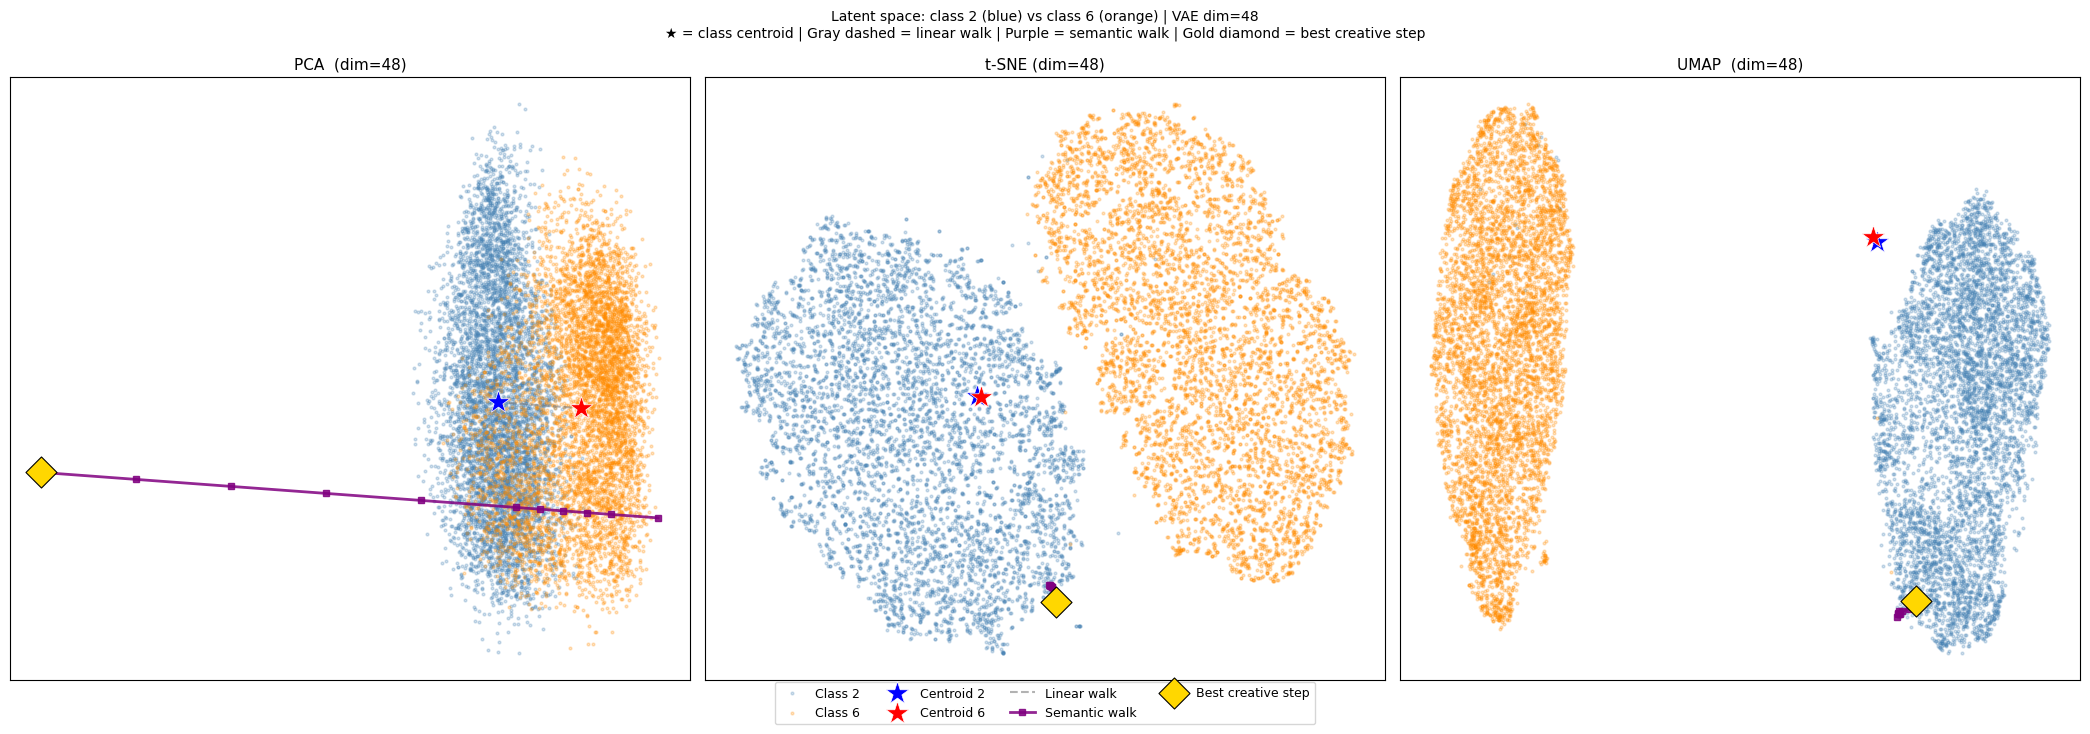

Saved -> cluster_viz_dim48.png


In [2]:
# ─────────────────────────────────────────────────────────────
# Standalone cluster visualization
# ─────────────────────────────────────────────────────────────

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from sklearn.neighbors import NearestNeighbors

try:
    import umap
    UMAP_AVAILABLE = True
    print('UMAP available')
except ImportError:
    UMAP_AVAILABLE = False
    print('umap not found — pip install umap-learn')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
VIZ_DIM = 48

# ── VAE definition (must match training) ──────────────────────
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=32):
        super().__init__()
        self.latent_dim  = latent_dim
        self.encoder = nn.Sequential(
            nn.Flatten(), nn.Linear(input_dim, hidden_dim), nn.ReLU())
        self.fc_mu     = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        self.decoder_net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, input_dim), nn.Sigmoid())
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)
    def decode(self, z):
        return self.decoder_net(z).view(-1, 1, 28, 28)
    def forward(self, x):
        mu, lv = self.encode(x)
        return self.decode(mu + torch.exp(0.5*lv)*torch.randn_like(mu)), mu, lv

# ── Load VAE ──────────────────────────────────────────────────
vae = VAE(latent_dim=VIZ_DIM, hidden_dim=400).to(device)
vae.load_state_dict(
    torch.load(f'saved_models_v3/vae_{VIZ_DIM}d.pt', map_location=device))
vae.eval()
print(f'Loaded vae_{VIZ_DIM}d.pt')

# ── Encode all training 2s and 6s ─────────────────────────────
def get_mnist_26(batch_size=128, train=True):
    dataset = torchvision.datasets.MNIST(
        'data', train=train, download=True, transform=transforms.ToTensor())
    mask = (dataset.targets == 2) | (dataset.targets == 6)
    return DataLoader(Subset(dataset, torch.where(mask)[0]),
                      batch_size=batch_size, shuffle=False)

train_loader = get_mnist_26(256, True)
test_loader  = get_mnist_26(256, False)

print('Encoding training images...')
all_mus, all_labels = [], []
with torch.no_grad():
    for x, y in train_loader:
        mu, _ = vae.encode(x.to(device))
        all_mus.append(mu.cpu()); all_labels.append(y)
latent_mus    = torch.cat(all_mus).numpy()    # (N, VIZ_DIM)
latent_labels = torch.cat(all_labels).numpy() # (N,)
mask2 = (latent_labels == 2)
mask6 = (latent_labels == 6)
print(f'Encoded {len(latent_mus)} images')

# ── Compute centroids ─────────────────────────────────────────
mu2_all      = torch.tensor(latent_mus[mask2])
mu6_all      = torch.tensor(latent_mus[mask6])
mu2_centroid = mu2_all.mean(0).numpy()
mu6_centroid = mu6_all.mean(0).numpy()

# ── Compute semantic direction + step size ────────────────────
direction_sem = torch.tensor(mu6_centroid - mu2_centroid)
direction_sem = direction_sem / (direction_sem.norm() + 1e-8)
mu_all  = torch.cat([mu2_all, mu6_all])
proj    = (mu_all - mu2_all.mean(0)) @ direction_sem
step_size = max(proj.std().item(), 0.5)

# ── Get first class-2 test anchor (matches notebook) ─────────
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        mu_batch, _ = vae.encode(x_batch.to(device))
        idx2 = torch.where(y_batch == 2)[0]
        if len(idx2) > 0:
            z_anchor = mu_batch[idx2[0]].cpu()
            break

# ── Build semantic walk waypoints ─────────────────────────────
alphas_wide = torch.tensor([-10., -8., -6., -4., -2., 0., 0.5, 1., 1.5, 2., 3.])
z_walk = torch.stack([
    z_anchor + a.item() * step_size * direction_sem
    for a in alphas_wide]).numpy()

# ── Build linear walk (centroid to centroid) ──────────────────
alphas_lin = torch.linspace(0, 1, 13)
z_lin = np.stack([
    (1-a.item())*mu2_centroid + a.item()*mu6_centroid
    for a in alphas_lin])

# ── Score walk to find best creative alpha ────────────────────
# (quick scoring — no GeneralAE needed for visualization)
vae.eval()
with torch.no_grad():
    imgs_walk = vae.decode(torch.tensor(z_walk, dtype=torch.float32).to(device)).cpu()

# Use simple NN distance as creativity proxy for visualization
nbrs     = NearestNeighbors(n_neighbors=1).fit(latent_mus)
nn_dists = nbrs.kneighbors(z_walk)[0][:,0]
novelty  = nn_dists / (1.0 + nn_dists)
# Best creative step = highest novelty that's not at the extremes
best_walk_idx = int(np.argmax(novelty))

# ── Stack all points for joint embedding ─────────────────────
n_train = len(latent_mus)
n_geo   = 0   # no geodesic if not computed — set to 0
n_lin   = len(z_lin)
n_walk  = len(z_walk)

all_pts = np.concatenate([
    latent_mus,
    mu2_centroid[None],
    mu6_centroid[None],
    z_lin,
    z_walk,
], axis=0).astype(np.float32)

print(f'Total points for embedding: {len(all_pts)}')

# ── Fit embeddings ────────────────────────────────────────────
print('Running PCA...')
pca_2d = PCA(n_components=2).fit_transform(all_pts)

print('Running t-SNE (~1 min)...')
tsne_2d = TSNE(n_components=2, perplexity=40,
               random_state=0, max_iter=1000).fit_transform(all_pts)

if UMAP_AVAILABLE:
    print('Running UMAP...')
    umap_2d = umap.UMAP(n_components=2, n_neighbors=30,
                         min_dist=0.1, random_state=0).fit_transform(all_pts)

# ── Unpack slices ─────────────────────────────────────────────
def unpack(emb):
    idx = 0
    tr_e  = emb[idx:idx+n_train];   idx += n_train
    m2_e  = emb[idx:idx+1];         idx += 1
    m6_e  = emb[idx:idx+1];         idx += 1
    lin_e = emb[idx:idx+n_lin];     idx += n_lin
    wlk_e = emb[idx:idx+n_walk];    idx += n_walk
    return tr_e, m2_e, m6_e, lin_e, wlk_e

# ── Plot ──────────────────────────────────────────────────────
def plot_clusters(emb, title, ax):
    tr_e, m2_e, m6_e, lin_e, wlk_e = unpack(emb)

    ax.scatter(tr_e[mask2,0], tr_e[mask2,1],
               c='steelblue',  s=4, alpha=0.25, label='Class 2', rasterized=True)
    ax.scatter(tr_e[mask6,0], tr_e[mask6,1],
               c='darkorange', s=4, alpha=0.25, label='Class 6', rasterized=True)

    ax.scatter(*m2_e[0], c='blue', s=300, marker='*',
               zorder=6, edgecolors='white', linewidths=0.5, label='Centroid 2')
    ax.scatter(*m6_e[0], c='red',  s=300, marker='*',
               zorder=6, edgecolors='white', linewidths=0.5, label='Centroid 6')

    ax.plot(lin_e[:,0], lin_e[:,1], '--', color='gray',
            linewidth=1.5, alpha=0.6, label='Linear walk', zorder=3)

    ax.plot(wlk_e[:,0], wlk_e[:,1], '-s', color='purple',
            linewidth=2, markersize=5, alpha=0.85,
            label='Semantic walk', zorder=4)

    ax.scatter(*wlk_e[best_walk_idx], c='gold', s=250, marker='D',
               zorder=7, edgecolors='black', linewidths=0.8,
               label='Best creative step')

    ax.set_title(title, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])


n_plots = 2 + (1 if UMAP_AVAILABLE else 0)
fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 7))

plot_clusters(pca_2d,  f'PCA  (dim={VIZ_DIM})',   axes[0])
plot_clusters(tsne_2d, f't-SNE (dim={VIZ_DIM})',   axes[1])
if UMAP_AVAILABLE:
    plot_clusters(umap_2d, f'UMAP  (dim={VIZ_DIM})', axes[2])

handles, lbls = axes[0].get_legend_handles_labels()
fig.legend(handles, lbls, loc='lower center', ncol=4,
           fontsize=9, bbox_to_anchor=(0.5, -0.05))

plt.suptitle(
    f'Latent space: class 2 (blue) vs class 6 (orange) | VAE dim={VIZ_DIM}\n'
    f'★ = class centroid | Gray dashed = linear walk | '
    f'Purple = semantic walk | Gold diamond = best creative step',
    fontsize=10)
plt.tight_layout()
plt.savefig(f'cluster_viz_dim{VIZ_DIM}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> cluster_viz_dim{VIZ_DIM}.png')